#### SCENARIO MODELING
Simulate Future policy paths

In [1]:
# Import necessary libs
import pandas as pd
import os
import matplotlib.pyplot as plt

In [2]:
# Load cleaned data
path = ("../data/processed/")

files = sorted([f for f in os.listdir(path) if f.endswith(".parquet")])

dfs = [pd.read_parquet(os.path.join(path, f)) for f in files]

df = pd.concat(dfs, ignore_index=True)

print(df.shape)

(3396556, 7)


In [3]:
# Extract Ethiopia Dataset
ethiopia_df = df[
    df["RecipientName"].str.contains("Ethiopia", case=False, na=False)
].copy()

print(ethiopia_df.shape)

(53372, 7)


In [4]:
# Step 1: Prepare Base Data

trend = ethiopia_df.groupby("Year")["USD_Commitment"].sum()
latest_value = trend.iloc[-1]

growth_rate = 0.087 # from previous result
climate_share = 0.128

In [5]:
# Step 2- Senario 1: Business As Usual (BAU)

years = 5
bau_projection = [latest_value * ((1 + growth_rate) ** i) for i in range(1, years + 1)]
print("BAU Projection: ",bau_projection)

BAU Projection:  [20730.540136263997, 22534.097128118963, 24494.56357826531, 26625.590609574396, 28942.016992607365]


Growth continues, but structural problems remain:
- low climate alignment
- weak carbon market readiness

#### Step 3- Scenario 2: Climate Policy Imporovment
Government improves:
   - climate tagging
   - project design

Assume:
   - climate share -> 30%
   
##### Better alignment with climate goals -> improved eligibility for:
   - climate finance
   - international funds
   - Article 6 participation

In [7]:
improved_climate_share = 0.30

#### Step 3- Scenario 2: Climate Policy Imporovment
Strategic Shift toward:
   - Mitigation
   - Carbon credit generation

Assume:
   - climate share -> 45%
   - growth rate increases -> 12%

In [8]:
high_growth = 0.12
high_climate_share = 0.45

carbon_market_projection = [
    latest_value * ((1 + high_growth) ** i) for i in range(1, years + 1)
]

print("Carbon Market Projection: ", carbon_market_projection)

Carbon Market Projection:  [21359.89416064, 23923.0814599168, 26793.85123510682, 30009.11338331964, 33610.206989318]


Ethiopia becomes:
- Active carbon credit supplier
- Strong player in Article 6 markets

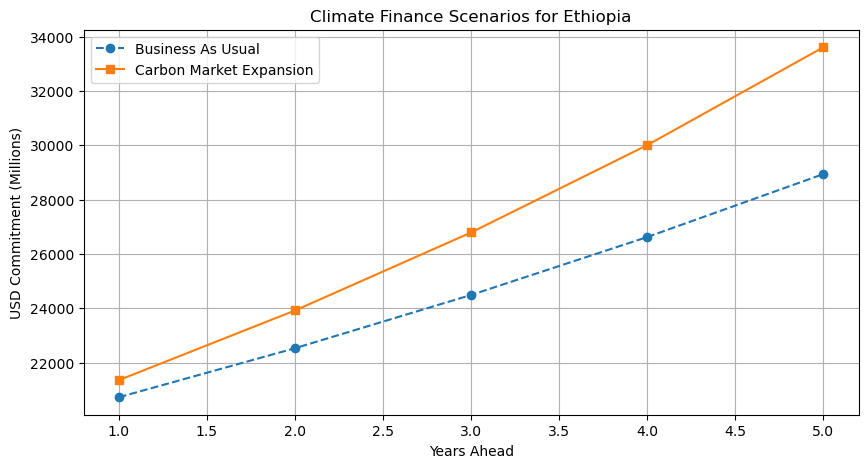

In [9]:
# Step 5- Compare Scenarios

years_range = list(range(1, years+1))

plt.figure(figsize=(10, 5))

plt.plot(
    years_range, bau_projection, 
    label="Business As Usual",
    linestyle="--", marker="o"
)

plt.plot(
    years_range, carbon_market_projection, 
    label="Carbon Market Expansion",
    linestyle="-", marker="s"
)

plt.title("Climate Finance Scenarios for Ethiopia")
plt.xlabel("Years Ahead")
plt.ylabel("USD Commitment (Millions)")

plt.legend()
plt.grid(True)

plt.savefig("../output/figures/scenario_projection.png", dpi=300, bbox_inches="tight")

plt.show()

#### Scenario analysis suggests that while Ethiopia’s climate finance is likely to grow under current trajectories, substantial gains in carbon market readiness and financial inflows depend on increasing the share of climate-targeted investments and prioritising mitigation-focused projects aligned with Article 6 mechanisms.